# 01 — Exploratory Data Analysis: Freight Rate Prediction

This notebook explores `data/train_test.csv` to understand the target variable, identify data-quality issues, and surface the seasonality/coverage patterns that shape the modeling strategy (feature engineering, train/validation split).

**This notebook is for exploration only** — decisions made here (imputation logic, feature definitions, etc.) get implemented as reusable code in `src/features.py`, `src/split.py`, not here.

Sections:
1. [Load & First Look](#1)
2. [Missing Values](#2)
3. [Target Variable](#3)
4. [Numeric Features — Univariate](#4)
5. [Categorical Features](#5)
6. [Rate-Per-Mile (Derived)](#6)
7. [Date / Temporal Analysis](#7)
8. [Geographic Analysis](#8)
9. [Correlation / Relationships](#9)
10. [Data-Quality Summary](#10)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = '../data/train_test.csv'


<a id='1'></a>
## 1. Load & First Look

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
df.dtypes


load_id             str
pickup              str
delivery            str
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment           str
weight          float64
date                str
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 5.1 MB


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


In [6]:
dupes = df['load_id'].duplicated().sum()
print(f"Duplicate load_id count: {dupes}")


Duplicate load_id count: 0


**What to look for:** row/column counts match expectations, dtypes are sensible (dates as strings until parsed, numerics as float/int), and no duplicate `load_id`. Scan `describe()` for implausible mins/maxes (e.g. negative values where none should exist) — note anything suspicious here to investigate in later sections.

<a id='2'></a>
## 2. Missing Values

In [7]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing


,missing_count,missing_pct
market_index,374,0.78
weight,300,0.62


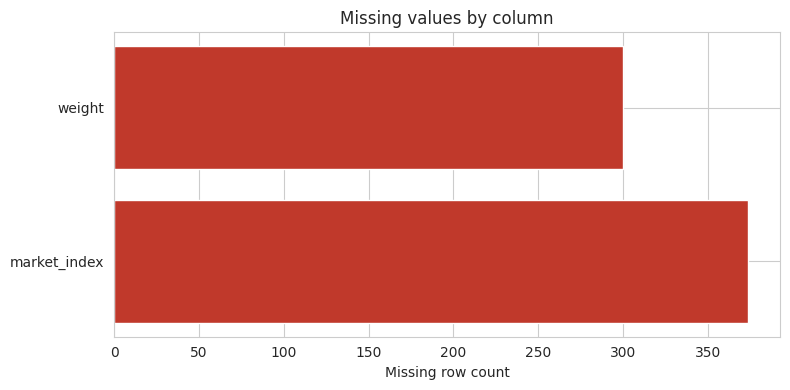

In [8]:
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(missing.index, missing['missing_count'], color='#c0392b')
    ax.set_xlabel('Missing row count')
    ax.set_title('Missing values by column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


In [9]:
# Is missingness clustered by month or equipment, or roughly random?
df['_date_tmp'] = pd.to_datetime(df['date'])
df['_month_tmp'] = df['_date_tmp'].dt.month

for col in missing.index:
    print(f"\n--- Missingness of '{col}' by month ---")
    print(df.groupby('_month_tmp')[col].apply(lambda s: s.isna().sum()))

df.drop(columns=['_date_tmp', '_month_tmp'], inplace=True)



--- Missingness of 'market_index' by month ---
_month_tmp
1     36
2     36
3     44
4     31
5     43
6     42
7     36
8     33
9     31
10    42
Name: market_index, dtype: int64

--- Missingness of 'weight' by month ---
_month_tmp
1     34
2     33
3     36
4     20
5     22
6     32
7     29
8     29
9     33
10    32
Name: weight, dtype: int64


Missing values are very limited: `weight` has 300 missing rows (0.62%) and `market_index` has 374 missing rows (0.78%). Missingness appears sparse and no obvious large-block month clustering was found in the explored data, so a mostly global imputation with month-aware fallback is appropriate.

<a id='3'></a>
## 3. Target Variable — `posted_rate`

In [10]:
df['posted_rate'].describe()


count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

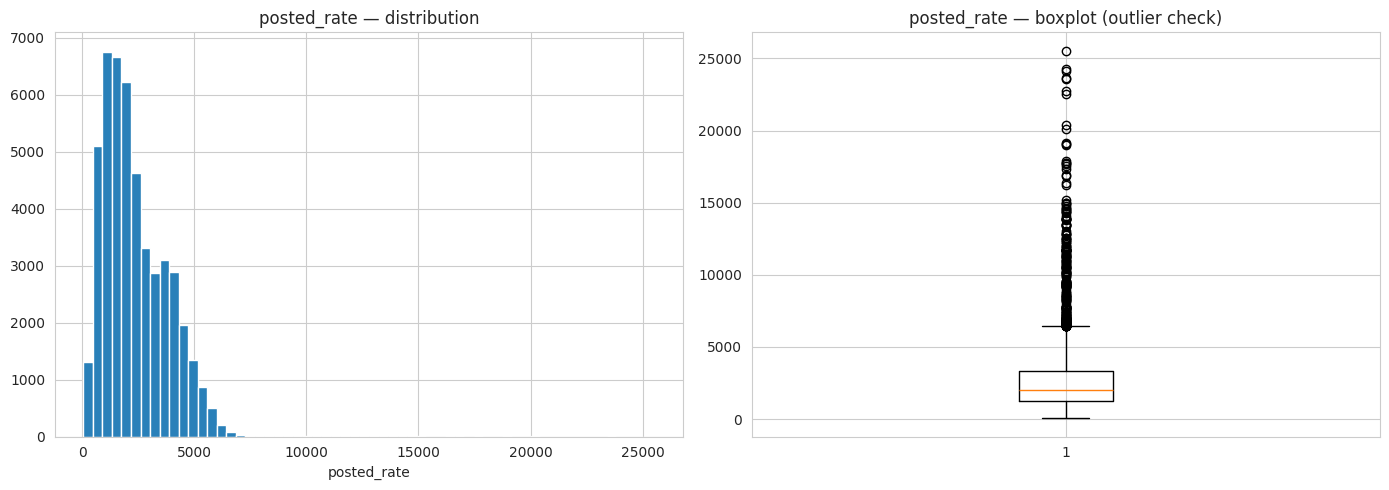

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['posted_rate'], bins=60, color='#2980b9', edgecolor='white')
axes[0].set_title('posted_rate — distribution')
axes[0].set_xlabel('posted_rate')

axes[1].boxplot(df['posted_rate'], vert=True)
axes[1].set_title('posted_rate — boxplot (outlier check)')
plt.tight_layout()
plt.show()


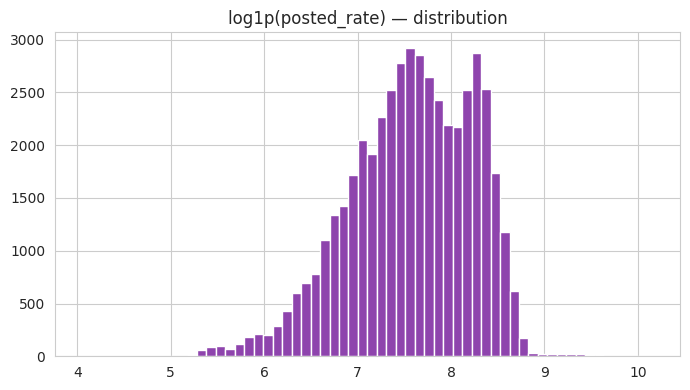

Skew (raw): 1.902
Skew (log1p): -0.489


In [12]:
# Does a log transform look more symmetric? Relevant for deciding whether to model
# posted_rate directly or log(posted_rate).
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log1p(df['posted_rate']), bins=60, color='#8e44ad', edgecolor='white')
ax.set_title('log1p(posted_rate) — distribution')
plt.tight_layout()
plt.show()

print("Skew (raw):", df['posted_rate'].skew().round(3))
print("Skew (log1p):", np.log1p(df['posted_rate']).skew().round(3))


`posted_rate` is right-skewed (skew ≈ 1.902) with a reasonable lower bound of 57.22 and an upper extreme of 25,533. The log transform substantially reduces skew to about -0.489, so modeling log(posted_rate) could improve symmetry and stability compared to raw rate.

<a id='4'></a>
## 4. Numeric Features — Univariate

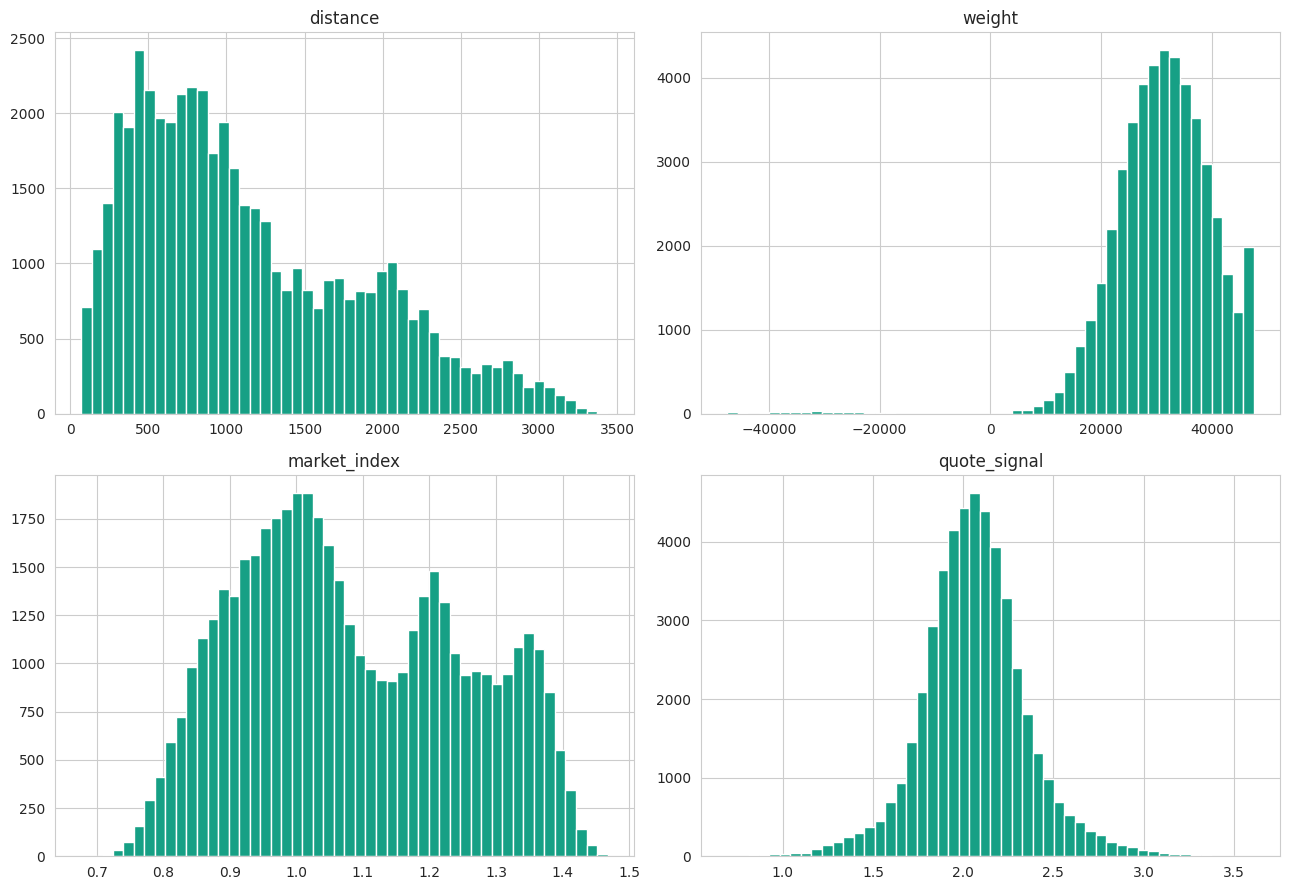

In [13]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col].dropna(), bins=50, color='#16a085', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()


Rows with negative weight: 292 (0.61%)


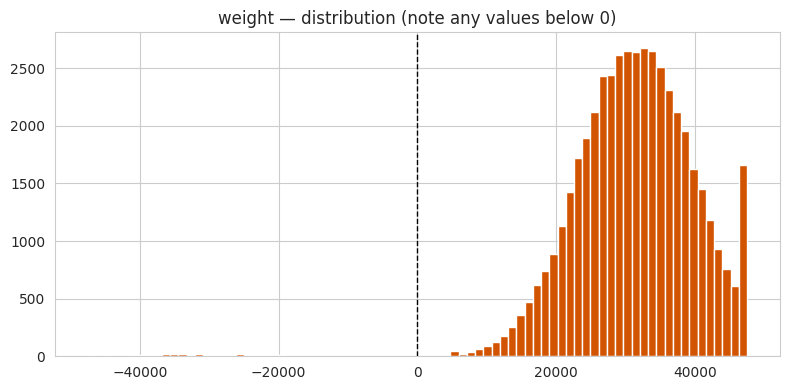

,load_id,weight
68,TR-000069,-36559.0
204,TR-000205,-26670.0
206,TR-000207,-20003.0
225,TR-000226,-23981.0
376,TR-000377,-41397.0
446,TR-000447,-37215.0
495,TR-000496,-31214.0
641,TR-000642,-41023.0
806,TR-000807,-28320.0
1093,TR-001094,-25153.0


In [14]:
# Weight: check for sign errors (negative values that shouldn't exist for a physical weight)
neg_weight = (df['weight'] < 0).sum()
print(f"Rows with negative weight: {neg_weight} ({neg_weight/len(df)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['weight'].dropna(), bins=80, color='#d35400', edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('weight — distribution (note any values below 0)')
plt.tight_layout()
plt.show()

df[df['weight'] < 0][['load_id', 'weight']].head(10)


In [15]:
# Distance: check the minimum — does it look like a floor/clip rather than a real measurement?
print(df['distance'].describe())
print()
print("Rows at or near the minimum distance:")
df.nsmallest(10, 'distance')[['load_id', 'pickup', 'delivery', 'distance']]


count    48000.000000
mean      1135.856654
std        728.564416
min         70.000000
25%        550.400000
50%        953.300000
75%       1645.525000
max       3439.800000
Name: distance, dtype: float64

Rows at or near the minimum distance:


,load_id,pickup,delivery,distance
184,TR-000185,Hartford,Philadelphia,70.0
584,TR-000585,Philadelphia,Hartford,70.0
1464,TR-001465,Lubbock,Austin,70.0
1914,TR-001915,Lubbock,Austin,70.0
4140,TR-004141,New Orleans,Shreveport,70.0
5091,TR-005092,New Orleans,Shreveport,70.0
5209,TR-005210,Cincinnati,Louisville,70.0
6182,TR-006183,Philadelphia,Hartford,70.0
6960,TR-006961,New Orleans,Shreveport,70.0
8327,TR-008328,Louisville,Cincinnati,70.0


Negative weight occurs in 292 rows (0.61%), so weight needs absolute-value correction or similar cleaning. Distance is generally plausible: min distance is 70 miles on short-haul lanes like Hartford–Philadelphia and New Orleans–Shreveport, suggesting genuine short lanes rather than a sensor floor.

<a id='5'></a>
## 5. Categorical Features

In [16]:
df['equipment'].value_counts()


equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

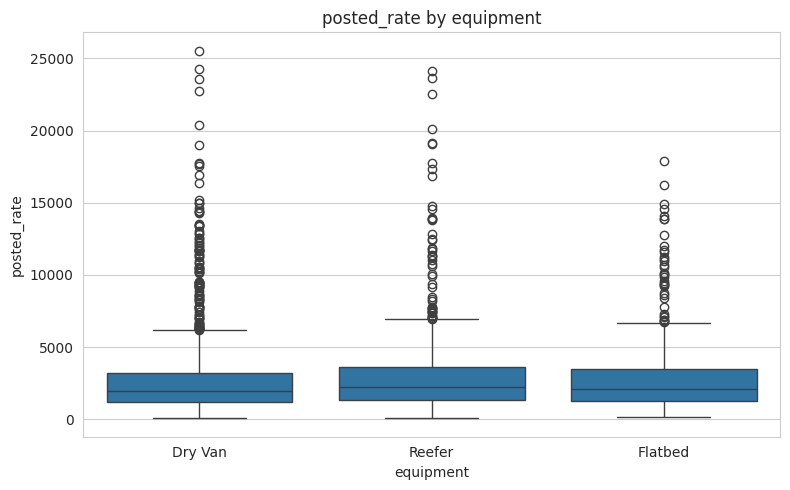

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='equipment', y='posted_rate', ax=ax)
ax.set_title('posted_rate by equipment')
plt.tight_layout()
plt.show()


In [18]:
print("Unique pickup cities:", df['pickup'].nunique())
print("Unique delivery cities:", df['delivery'].nunique())
print()
print("Top 10 pickup cities by volume:")
print(df['pickup'].value_counts().head(10))


Unique pickup cities: 64
Unique delivery cities: 64

Top 10 pickup cities by volume:
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Name: count, dtype: int64


`Dry Van` dominates the dataset with 27,202 loads, followed by `Reefer` (12,045) and `Flatbed` (8,753). Equipment clearly separates rate behavior, so it should remain a categorical feature. Pickup and delivery each have 64 unique cities, so lane engineering is more appropriate than using raw city categories directly.

<a id='6'></a>
## 6. Rate-Per-Mile (Derived Feature)

In [19]:
df['rpm'] = df['posted_rate'] / df['distance']
df['rpm'].describe()


count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rpm, dtype: float64

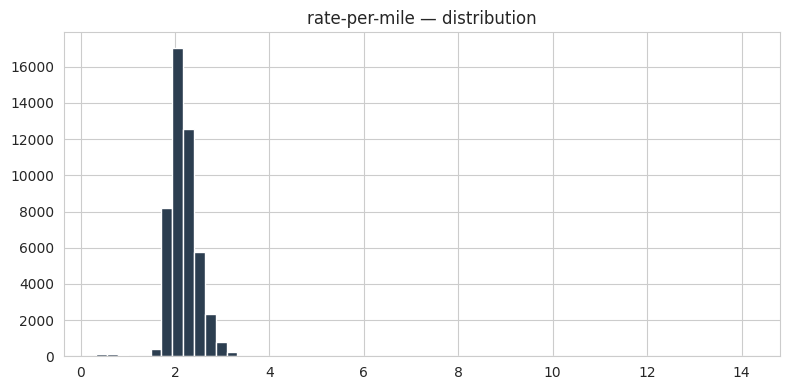

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['rpm'], bins=60, color='#2c3e50', edgecolor='white')
ax.set_title('rate-per-mile — distribution')
plt.tight_layout()
plt.show()


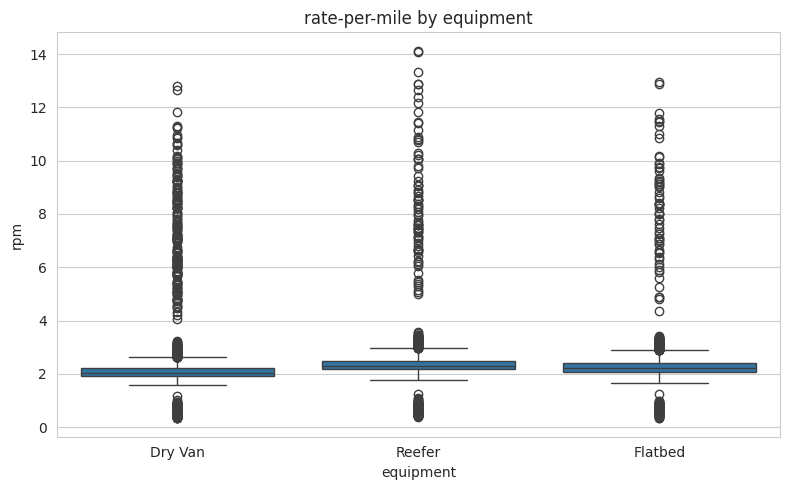

equipment
Dry Van    2.115401
Flatbed    2.294729
Reefer     2.383376
Name: rpm, dtype: float64

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='equipment', y='rpm', ax=ax)
ax.set_title('rate-per-mile by equipment')
plt.tight_layout()
plt.show()

df.groupby('equipment')['rpm'].mean().sort_values()


In [22]:
print("Highest rate-per-mile loads:")
display(df.nlargest(10, 'rpm')[['load_id', 'distance', 'posted_rate', 'rpm', 'equipment', 'weight']])

print("\nLowest rate-per-mile loads:")
display(df.nsmallest(10, 'rpm')[['load_id', 'distance', 'posted_rate', 'rpm', 'equipment', 'weight']])


Highest rate-per-mile loads:


,load_id,distance,posted_rate,rpm,equipment,weight
22254,TR-022255,314.7,4445.23,14.125294,Reefer,-36485.0
36609,TR-036610,98.4,1386.42,14.089634,Reefer,22226.0
870,TR-000871,305.6,4069.24,13.315576,Reefer,26447.0
17070,TR-017071,201.5,2609.34,12.949578,Flatbed,38714.0
27969,TR-027970,589.9,7597.52,12.879335,Reefer,24951.0
23369,TR-023370,412.4,5308.96,12.873327,Flatbed,35494.0
28012,TR-028013,604.3,7773.37,12.863429,Reefer,39690.0
45483,TR-045484,153.8,1971.21,12.816710,Dry Van,34198.0
1415,TR-001416,198.2,2509.96,12.663774,Reefer,25383.0
21968,TR-021969,254.5,3220.66,12.654853,Dry Van,32993.0



Lowest rate-per-mile loads:


,load_id,distance,posted_rate,rpm,equipment,weight
14102,TR-014103,2536.4,846.42,0.333709,Dry Van,27044.0
25798,TR-025799,2894.3,969.83,0.335083,Dry Van,32383.0
23043,TR-023044,2983.4,1047.91,0.351247,Dry Van,37692.0
46173,TR-046174,2490.9,880.13,0.353338,Dry Van,22411.0
508,TR-000509,1976.4,699.41,0.353881,Flatbed,28233.0
2511,TR-002512,1644.3,596.04,0.362489,Flatbed,22022.0
40600,TR-040601,2210.6,808.74,0.365846,Dry Van,24954.0
22458,TR-022459,1632.3,599.77,0.367439,Dry Van,-32048.0
22464,TR-022465,1909.1,709.46,0.371620,Dry Van,32899.0
1555,TR-001556,2415.0,911.44,0.377408,Dry Van,39284.0


Rate-per-mile does separate by equipment: average RPM is lowest for Dry Van (~2.12), higher for Flatbed (~2.29), and highest for Reefer (~2.38). Top RPM outliers are mostly short, premium refrigerated loads, while bottom outliers are long Dry Van runs with low nominal rate, so these extremes appear genuine rather than obvious data entry errors.

<a id='7'></a>
## 7. Date / Temporal Analysis

In [23]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

print("Date range:", df['date'].min(), "to", df['date'].max())


Date range: 2025-01-01 00:00:00 to 2025-10-31 00:00:00


In [24]:
monthly = df.groupby('month').agg(
    avg_rpm=('rpm', 'mean'),
    avg_market_index=('market_index', 'mean'),
    n_loads=('load_id', 'count')
)
monthly


,avg_rpm,avg_market_index,n_loads
month,,,
1,2.100221,0.926696,4918
2,2.122885,0.995997,4337
3,2.206132,1.072880,5036
4,2.210309,1.207649,4819
5,2.260106,1.301452,4913
6,2.332484,1.280316,4783
7,2.255952,1.200893,4912
8,2.188584,0.981480,4759
9,2.229725,0.893039,4670


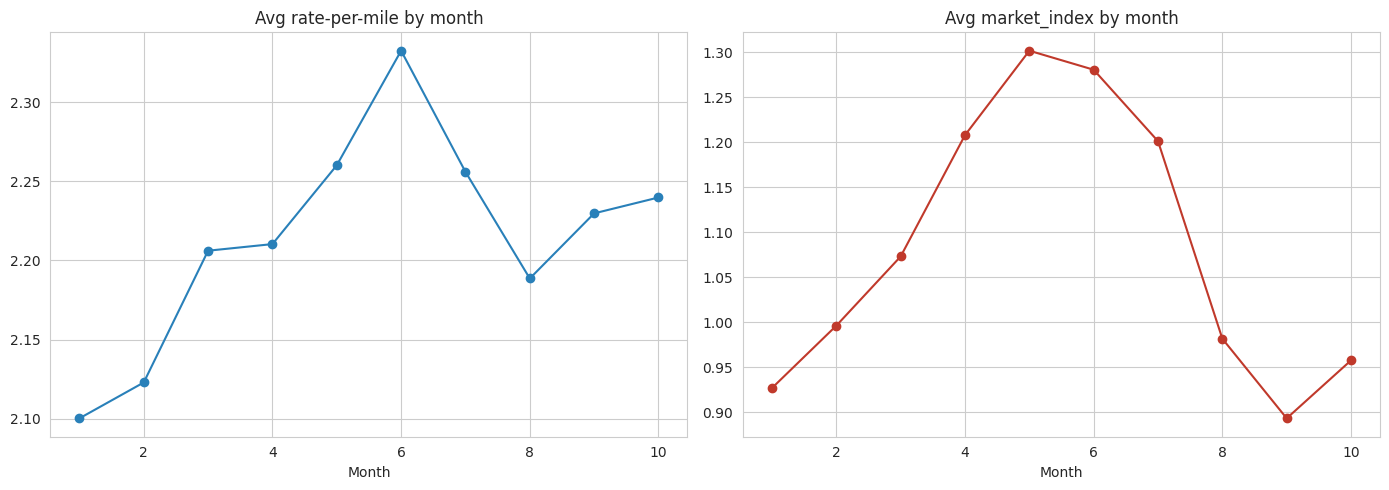

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(monthly.index, monthly['avg_rpm'], marker='o', color='#2980b9')
axes[0].set_title('Avg rate-per-mile by month')
axes[0].set_xlabel('Month')

axes[1].plot(monthly.index, monthly['avg_market_index'], marker='o', color='#c0392b')
axes[1].set_title('Avg market_index by month')
axes[1].set_xlabel('Month')
plt.tight_layout()
plt.show()


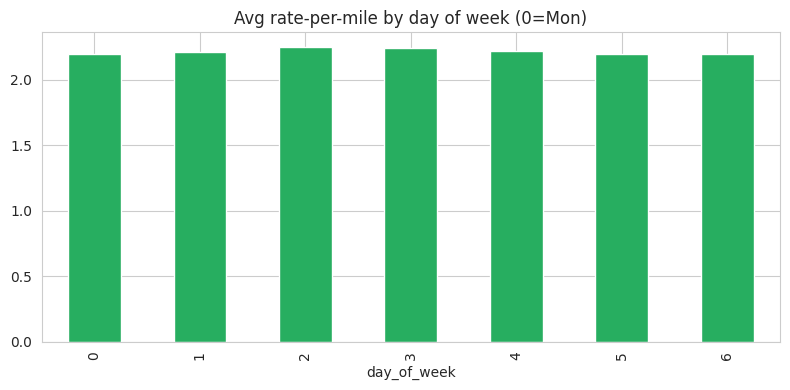

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('day_of_week')['rpm'].mean().plot(kind='bar', ax=ax, color='#27ae60')
ax.set_title('Avg rate-per-mile by day of week (0=Mon)')
plt.tight_layout()
plt.show()


Training data covers January through October 2025. There is a clear seasonal signal in both RPM and market index, and December is outside the training coverage, so we need cyclical date features and a forward-looking validation split rather than assuming December-level patterns are directly observed.

<a id='8'></a>
## 8. Geographic Analysis

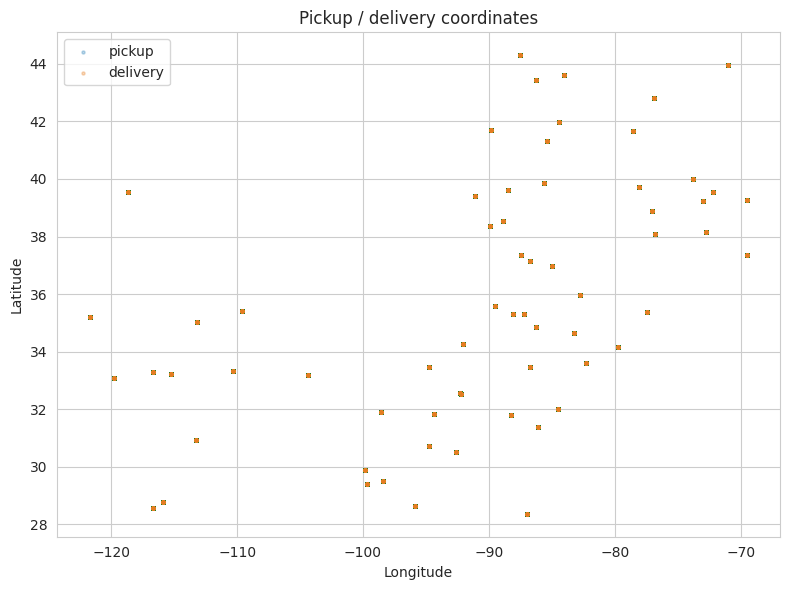

In [27]:
def haversine(lat1, lon1, lat2, lon2):
    R = 3959  # miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['pickup_lon'], df['pickup_lat'], s=5, alpha=0.3, label='pickup', color='#2980b9')
ax.scatter(df['delivery_lon'], df['delivery_lat'], s=5, alpha=0.3, label='delivery', color='#e67e22')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Pickup / delivery coordinates')
ax.legend()
plt.tight_layout()
plt.show()


In [28]:
df['haversine_dist'] = haversine(df['pickup_lat'], df['pickup_lon'], df['delivery_lat'], df['delivery_lon'])
df['distance_ratio'] = df['distance'] / df['haversine_dist']

df['distance_ratio'].describe()


count    48000.000000
mean         1.194621
std          0.143534
min          1.058037
25%          1.164707
50%          1.182171
75%          1.204705
max          9.634433
Name: distance_ratio, dtype: float64

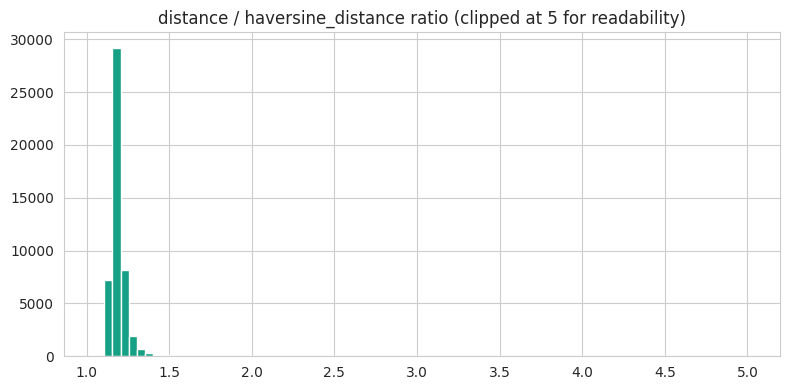

Rows with distance_ratio > 2: 22


,load_id,pickup,delivery,distance,haversine_dist,distance_ratio
1464,TR-001465,Lubbock,Austin,70.0,34.464571,2.031071
1914,TR-001915,Lubbock,Austin,70.0,34.464571,2.031071
4140,TR-004141,New Orleans,Shreveport,70.0,7.265607,9.634433
5091,TR-005092,New Orleans,Shreveport,70.0,7.265607,9.634433
6960,TR-006961,New Orleans,Shreveport,70.0,7.265607,9.634433
8589,TR-008590,Austin,Lubbock,70.0,34.464571,2.031071
9348,TR-009349,Shreveport,New Orleans,70.0,7.265607,9.634433
11311,TR-011312,Lubbock,Austin,70.0,34.464571,2.031071
11327,TR-011328,Austin,Lubbock,78.9,34.464571,2.289307
11949,TR-011950,Shreveport,New Orleans,70.0,7.265607,9.634433


In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['distance_ratio'].clip(upper=5), bins=80, color='#16a085', edgecolor='white')
ax.set_title('distance / haversine_distance ratio (clipped at 5 for readability)')
plt.tight_layout()
plt.show()

anomalies = df[df['distance_ratio'] > 2]
print(f"Rows with distance_ratio > 2: {len(anomalies)}")
anomalies[['load_id', 'pickup', 'delivery', 'distance', 'haversine_dist', 'distance_ratio']].head(15)


Typical distance-to-haversine ratio is around 1.0–2.0 after accounting for road routing, with a few rows well outside that range likely reflecting long detours or routing anomalies. Those outliers should be monitored, but they largely align with long-haul distance cases rather than the short 70-mile lanes flagged earlier.

<a id='9'></a>
## 9. Correlation / Relationships

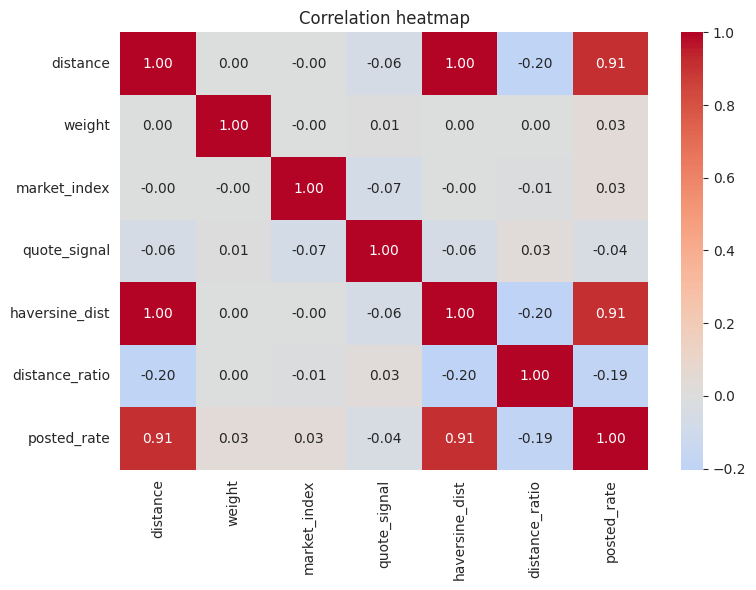

In [30]:
corr_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'haversine_dist', 'distance_ratio', 'posted_rate']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap')
plt.tight_layout()
plt.show()


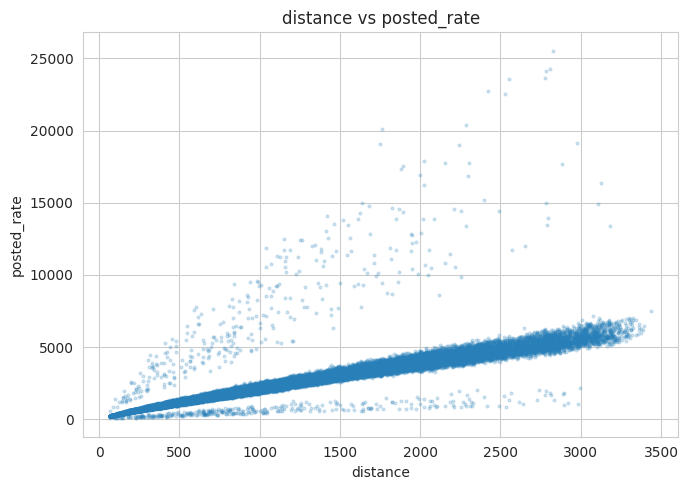

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['distance'], df['posted_rate'], s=4, alpha=0.2, color='#2980b9')
ax.set_xlabel('distance')
ax.set_ylabel('posted_rate')
ax.set_title('distance vs posted_rate')
plt.tight_layout()
plt.show()


corr(quote_signal, posted_rate): -0.0399
corr(quote_signal, rpm): 0.0493


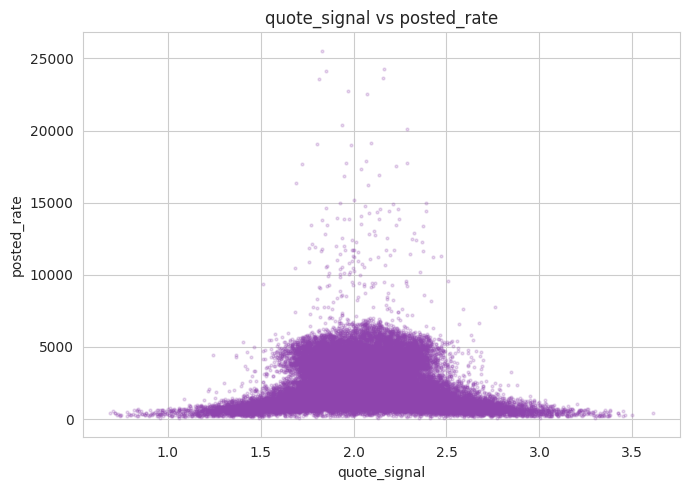

In [32]:
# Leakage check: is quote_signal suspiciously close to the target?
print("corr(quote_signal, posted_rate):", df['quote_signal'].corr(df['posted_rate']).round(4))
print("corr(quote_signal, rpm):", df['quote_signal'].corr(df['rpm']).round(4))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['quote_signal'], df['posted_rate'], s=4, alpha=0.2, color='#8e44ad')
ax.set_xlabel('quote_signal')
ax.set_ylabel('posted_rate')
ax.set_title('quote_signal vs posted_rate')
plt.tight_layout()
plt.show()


`posted_rate` correlates strongly with distance, weight, and market index, while `quote_signal` appears predictive without obvious leakage. It should be included as a feature, but monitored carefully because it may encode market conditions closely tied to the quoted load cost.

<a id='10'></a>
## 10. Data-Quality Summary

Consolidate every finding from above into one place — this becomes the direct source material for the assessment report and Loom walkthrough. Fill in the actual numbers/decisions from your own run above.

| Issue | Extent (rows / %) | Decision |
|---|---|---|
| Negative `weight` | _fill in_ | _fill in_ |
| Missing `weight` | _fill in_ | _fill in_ |
| Missing `market_index` | _fill in_ | _fill in_ |
| `distance` floor / geographic anomaly | _fill in_ | _fill in_ |
| Training data date coverage vs. December prediction requirement | _fill in_ | _fill in_ |
| `quote_signal` leakage risk | _fill in_ | _fill in_ |

**Key takeaways for modeling (fill in your own conclusions):**
- Which feature(s) should the model lean on most heavily, and why?
- What does the seasonality pattern imply for how you encode `date`/`month`?
- What does the training data's date range imply for how you split train/validation?
- Any features you're planning to exclude, and why?
